# Reproduction plots

Mirrors the authors' `eval.ipynb`, for our runs. For every task and eval it shows the authors' released checkpoint (`pretrained`) and our run side by side, and saves each as its own figure in `figures/<task>/`:

- `<eval>.png`: the original, from the released checkpoint, as their notebook plots it
- `<eval>_repr.png`: the same plot from our run

The released checkpoints have fewer evals than ours for some tasks, and none for the Black-Scholes tasks; those evals only get `_repr.png`.

In [1]:
from collections import OrderedDict
import re
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm.notebook import tqdm

from eval import get_run_metrics, read_run_dir, get_model_from_run
from plot_utils import basic_plot, collect_results, relevant_model_names
from tasks import BS_TASKS

%matplotlib inline
%load_ext autoreload
%autoreload 2

sns.set_theme('notebook', 'darkgrid')
palette = sns.color_palette('colorblind')

run_dir = "../models"
fig_dir = "../figures"

In [2]:
df = read_run_dir(run_dir)
df  # list all the runs in our run_dir

,run_id,task,model,kwargs,num_tasks,num_examples,n_dims,n_layer,n_head,run_name
0,dc2e5022-dd53-436f-89fb-8c0a6b4fa3ff,bs_flat,Transformer,,-1,-1,2,12,8,bs_flat_standard
1,61af878c-034c-459f-b647-78b71b2bcfdf,bs_smile,Transformer,,-1,-1,2,12,8,bs_smile_standard
3,pretrained,decision_tree,Transformer,depth=4,-1,-1,20,12,8,decision_tree_pretrained
2,53417d4c-9a6c-4c1a-ae09-3df8c0af2676,decision_tree,Transformer,depth=4,-1,-1,20,12,8,decision_tree_standard
5,pretrained,linear_regression,Transformer,,-1,-1,20,12,8,linear_regression_pretrained
4,52e59405-04a5-4e41-8caa-6bc1e02d8304,linear_regression,Transformer,,-1,-1,20,12,8,linear_regression_standard
7,pretrained,relu_2nn_regression,Transformer,hidden_layer_size=100,-1,-1,20,12,8,relu_2nn_regression_pretrained
6,0c3f3424-0387-4099-bff0-004968547236,relu_2nn_regression,Transformer,hidden_layer_size=100,-1,-1,20,12,8,relu_2nn_regression_standard
9,pretrained,sparse_linear_regression,Transformer,sparsity=3,-1,-1,20,12,8,sparse_regression_pretrained
8,56bb1fd5-0882-411f-92ac-7e2109f3f4d0,sparse_linear_regression,Transformer,sparsity=3,-1,-1,20,12,8,sparse_regression_standard


In [3]:
# our run for each task; "pretrained" is the authors' released checkpoint
our_run_ids = {
    "linear_regression": "52e59405-04a5-4e41-8caa-6bc1e02d8304",
    "sparse_linear_regression": "56bb1fd5-0882-411f-92ac-7e2109f3f4d0",
    "decision_tree": "53417d4c-9a6c-4c1a-ae09-3df8c0af2676",
    "relu_2nn_regression": "0c3f3424-0387-4099-bff0-004968547236",
    "bs_flat": "dc2e5022-dd53-436f-89fb-8c0a6b4fa3ff",
    "bs_smile": "61af878c-034c-459f-b647-78b71b2bcfdf",
}

tasks = [
    "linear_regression",
    "sparse_linear_regression",
    "decision_tree",
    "relu_2nn_regression",
    "bs_flat",
    "bs_smile",
]

# Plot pre-computed metrics

In [4]:
def trivial_level(task, name, n_dims):
    if task in BS_TASKS:
        # targets are standardised and never rescaled; only the noise adds to it
        return 1 + 0.05**2 if name == "noisy" else 1.0
    scale = float(name.split("=")[-1])**2 if "scale" in name else 1.0
    return scale * ((1 + 1 / n_dims) if "noisy" in name else 1.0)


def load_run(task, run_id):
    """Metrics of one run, keeping only the evals that were computed for it."""
    run_path = os.path.join(run_dir, task, run_id)
    if not os.path.exists(run_path):
        return {}, None

    def valid_row(r):
        return r.task == task and r.run_id == run_id

    metrics = collect_results(run_dir, df, valid_row=valid_row)
    _, conf = get_model_from_run(run_path, only_conf=True)
    return {k: v for k, v in metrics.items() if "Transformer" in v}, conf.model.n_dims


def plot_eval(task, name, metric, n_dims, title, ax=None):
    models = [m for m in relevant_model_names[task] if m in metric]
    trivial = trivial_level(task, name, n_dims)
    fig, ax = basic_plot(metric, models=models, trivial=trivial, ax=ax)
    ax.set_title(title)

    if task in BS_TASKS:
        # calibration reaches ~1e-5, far below the no-context floor
        ax.set_yscale("log")
        ax.set_ylim(1e-6, 3)
    elif name != "standard":
        if "ortho" in name:
            ax.set_xlim(-1, n_dims - 1)
        ax.set_ylim(-.1 * trivial, 1.5 * trivial)
    return fig, ax


def plot_task(task):
    released, _ = load_run(task, "pretrained")
    ours, n_dims = load_run(task, our_run_ids[task])
    os.makedirs(os.path.join(fig_dir, task), exist_ok=True)

    # "standard" first, then any OOD metrics
    for name in sorted(ours, key=lambda name: name != "standard"):
        # (metric, title, file suffix): released on the left, ours on the right
        panels = [(ours[name], "ours", "_repr")]
        if name in released:
            panels.insert(0, (released[name], "released", ""))

        # one figure per panel on disk
        for metric, who, suffix in panels:
            fig, _ = plot_eval(task, name, metric, n_dims, f"{task}: {name} ({who})")
            fig.savefig(os.path.join(fig_dir, task, f"{name}{suffix}.png"), dpi=150, bbox_inches="tight")
            plt.close(fig)

        # both panels side by side in the notebook
        fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 3), sharey=True, squeeze=False)
        for ax, (metric, who, _) in zip(axes[0], panels):
            plot_eval(task, name, metric, n_dims, who, ax=ax)
        for ax in axes[0][:-1]:  # the legend on the right covers both
            ax.get_legend().remove()
        for ax in axes[0][1:]:
            ax.set_ylabel("")
        fig.suptitle(f"{task}: {name}", y=1.05)
        plt.show()

linear_regression_pretrained pretrained



  0%|          | 0/15 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<?, ?it/s]

linear_regression_standard 52e59405-04a5-4e41-8caa-6bc1e02d8304



  0%|          | 0/15 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 10665.29it/s]

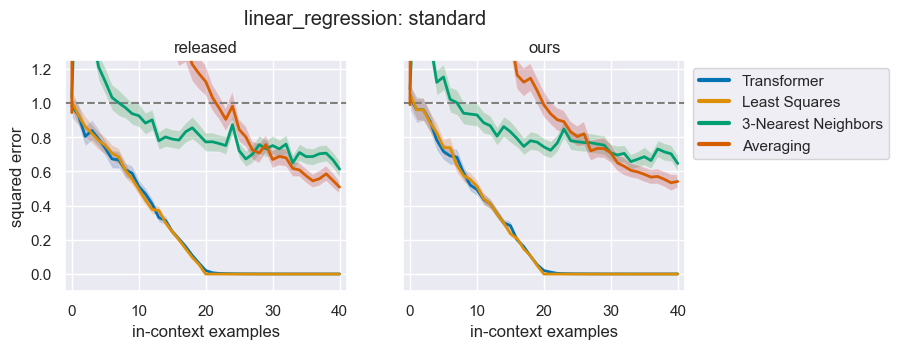

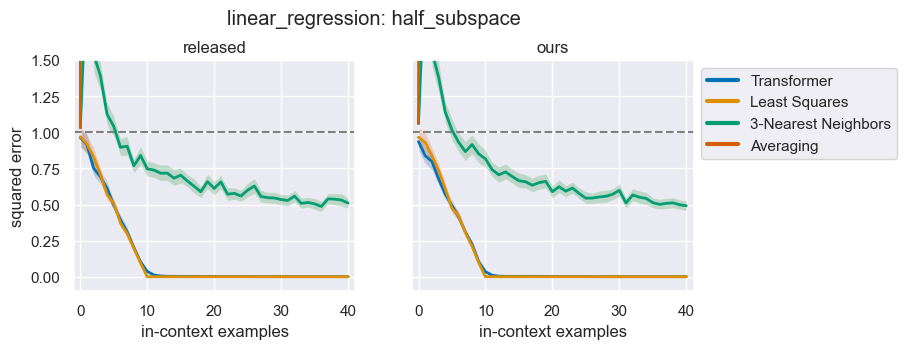

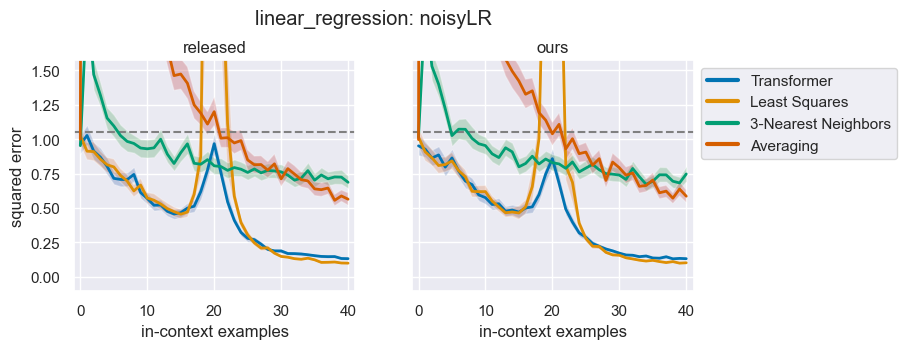

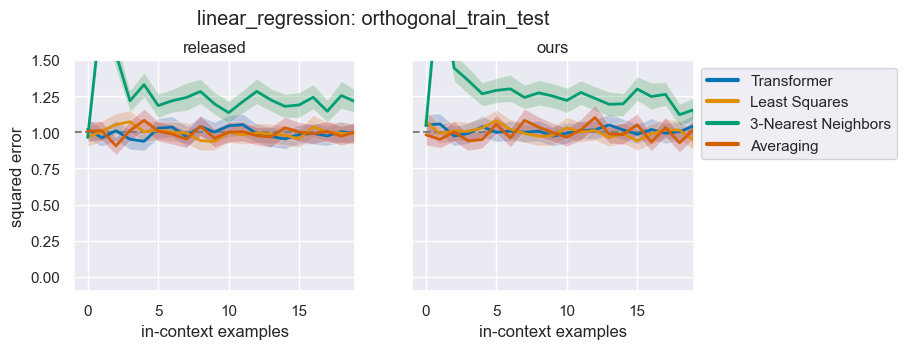

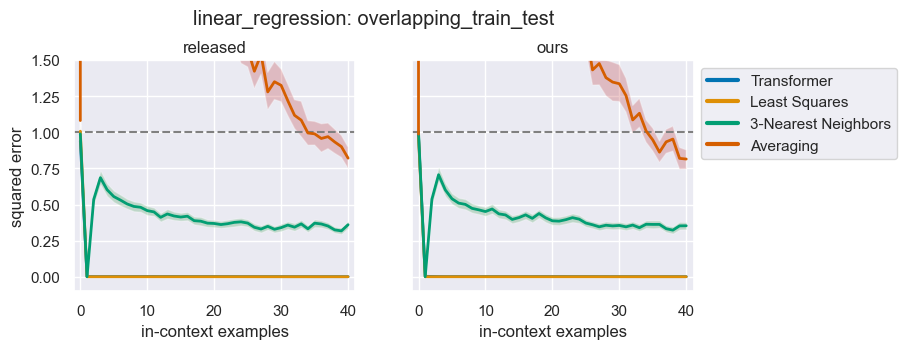

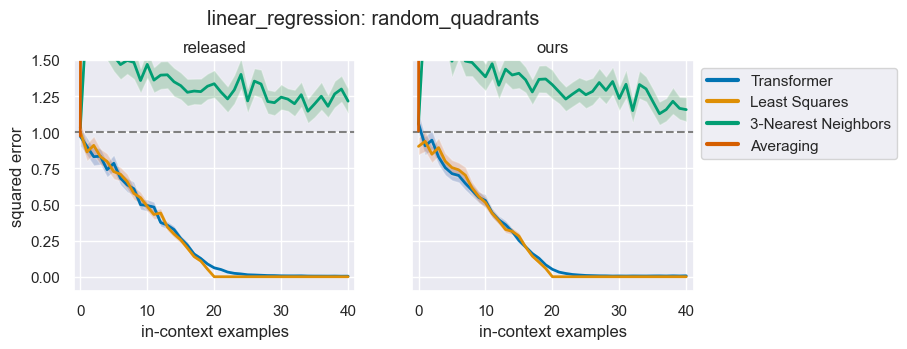

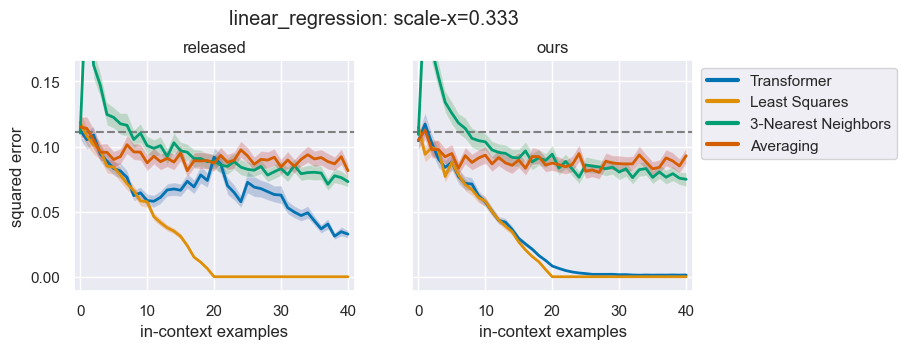

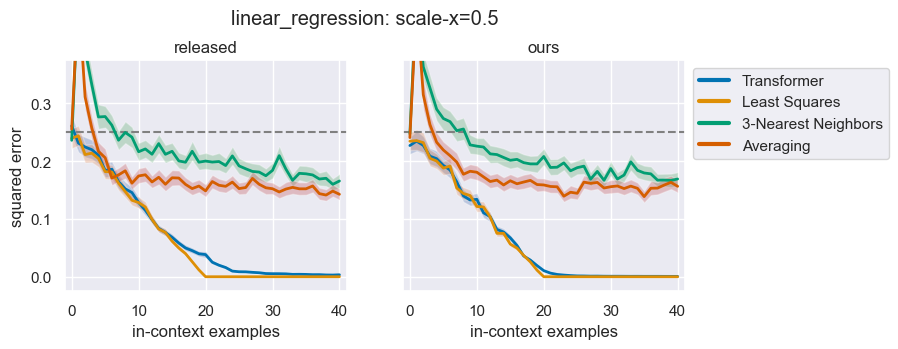

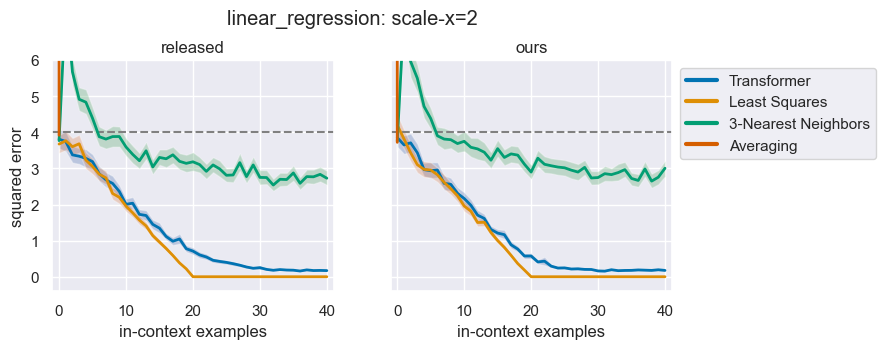

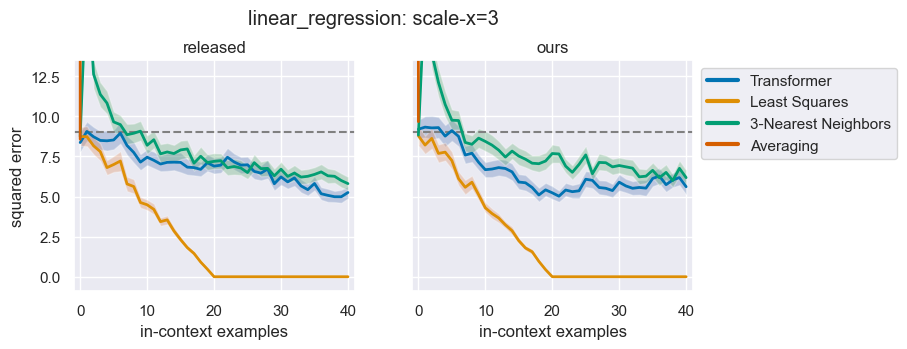

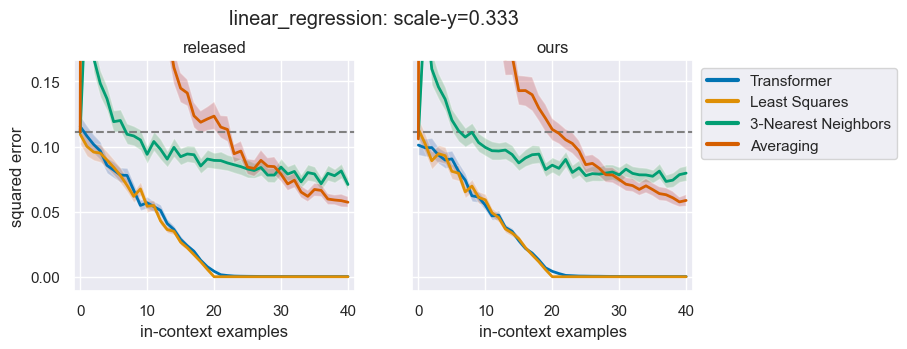

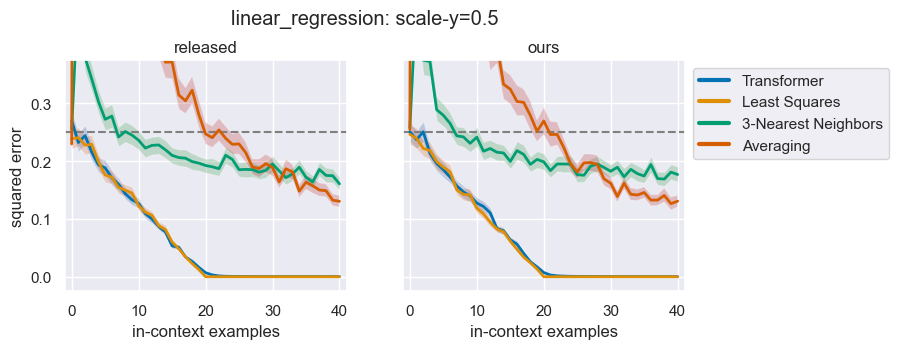

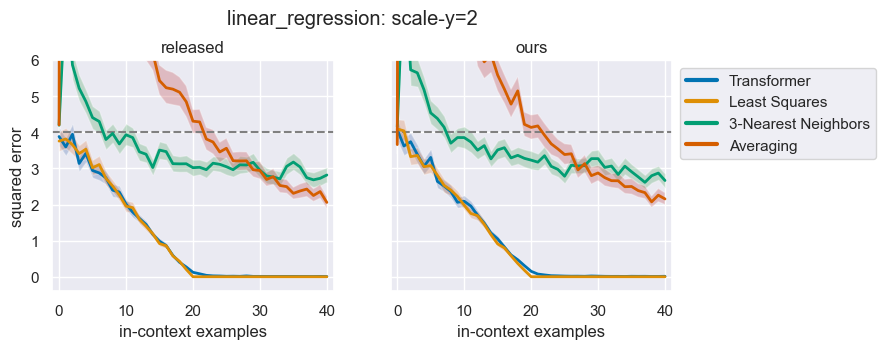

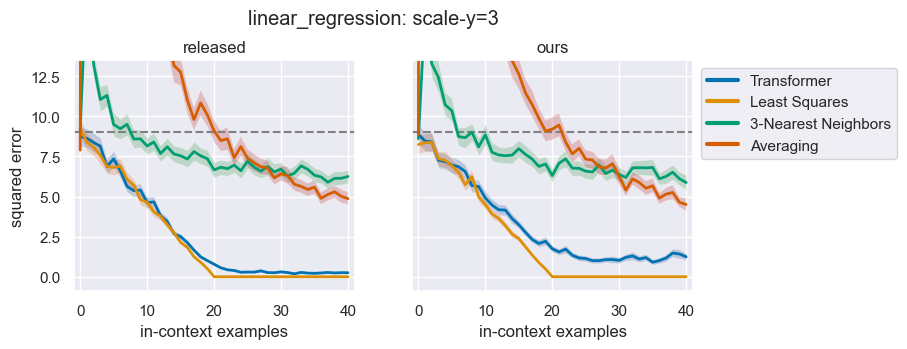

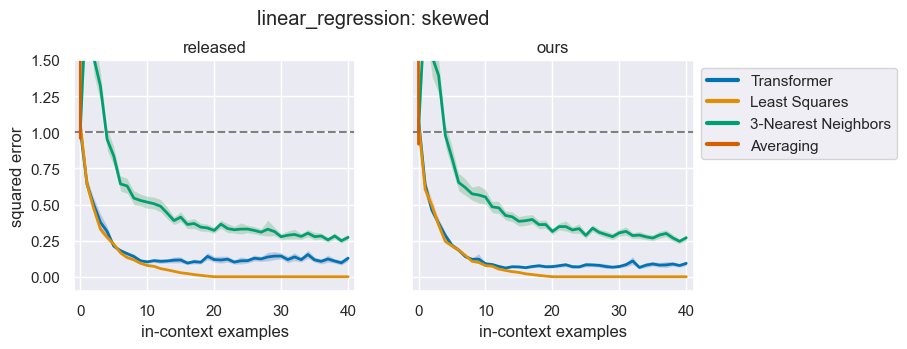

sparse_regression_pretrained pretrained



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<?, ?it/s]

sparse_regression_standard 56bb1fd5-0882-411f-92ac-7e2109f3f4d0



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<?, ?it/s]

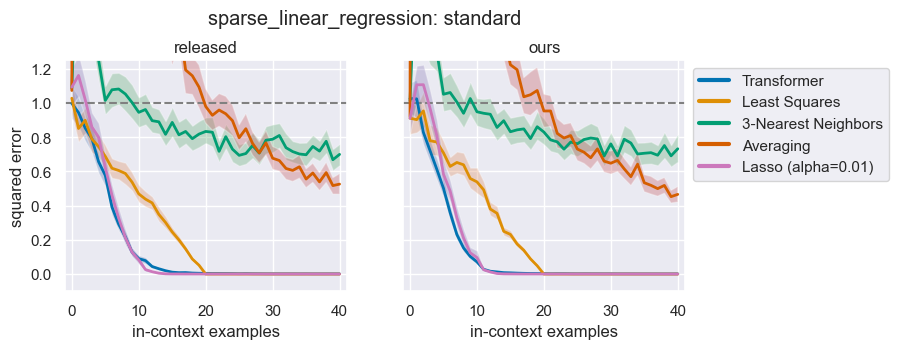

decision_tree_pretrained pretrained



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<?, ?it/s]

decision_tree_standard 53417d4c-9a6c-4c1a-ae09-3df8c0af2676



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<?, ?it/s]

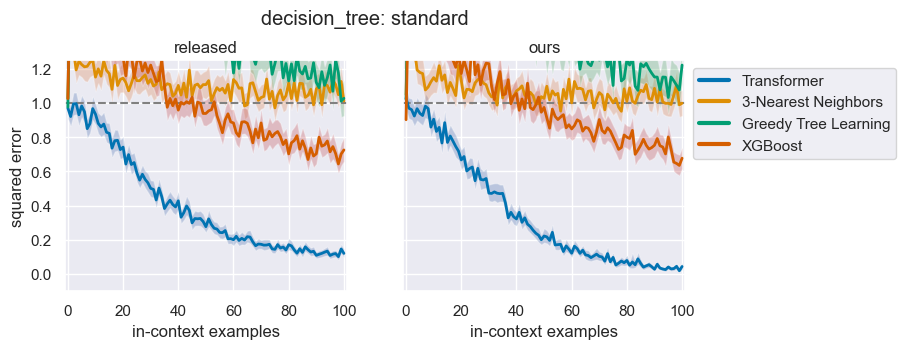

relu_2nn_regression_pretrained pretrained



  0%|          | 0/2 [00:00<?, ?it/s]


100%|██████████| 2/2 [00:00<?, ?it/s]

relu_2nn_regression_standard 0c3f3424-0387-4099-bff0-004968547236



  0%|          | 0/2 [00:00<?, ?it/s]


100%|██████████| 2/2 [00:00<00:00, 2007.32it/s]

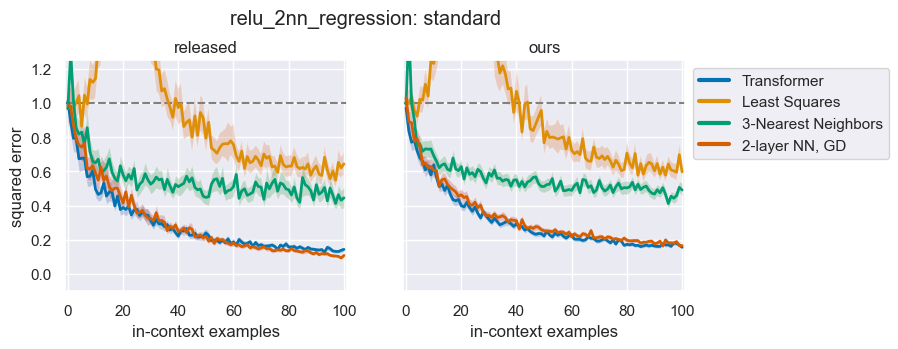

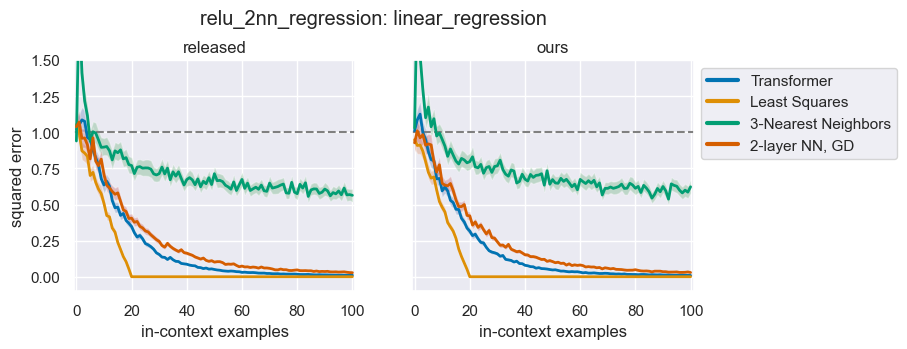

bs_flat_standard dc2e5022-dd53-436f-89fb-8c0a6b4fa3ff



  0%|          | 0/6 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<?, ?it/s]

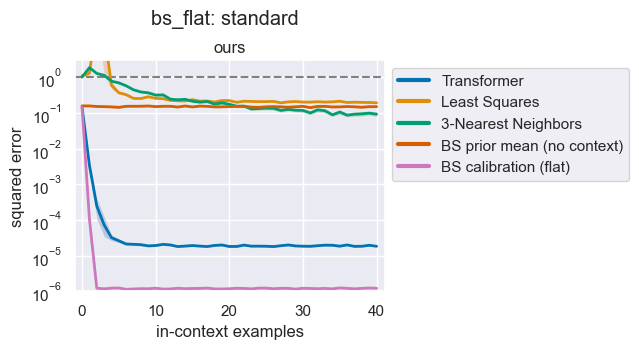

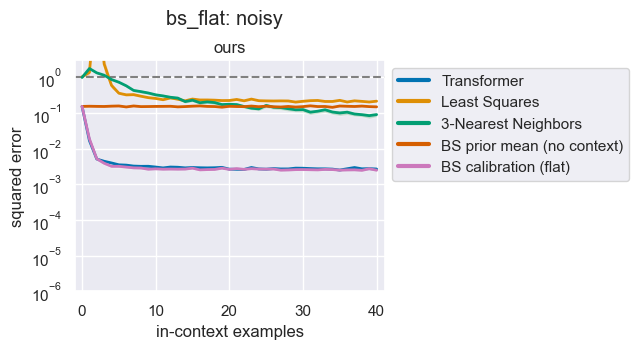

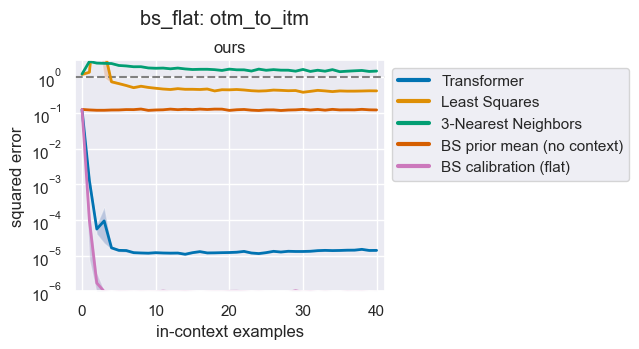

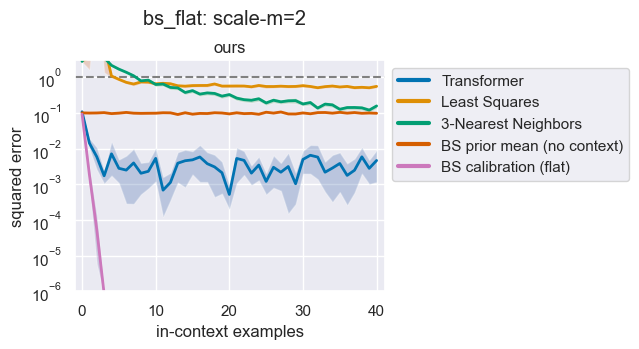

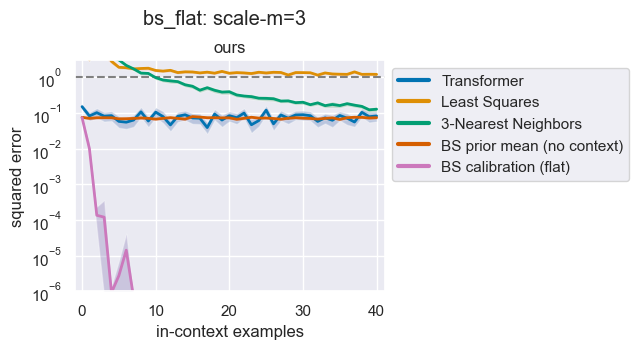

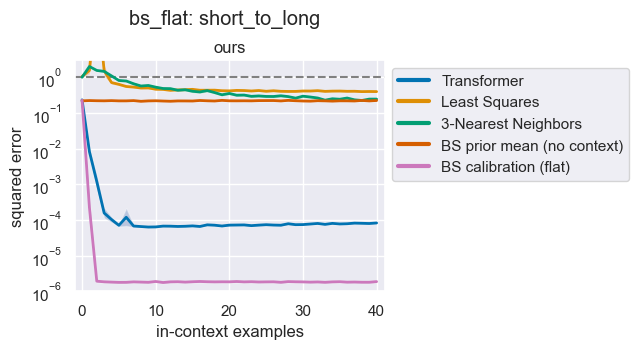

bs_smile_standard 61af878c-034c-459f-b647-78b71b2bcfdf



  0%|          | 0/6 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<?, ?it/s]

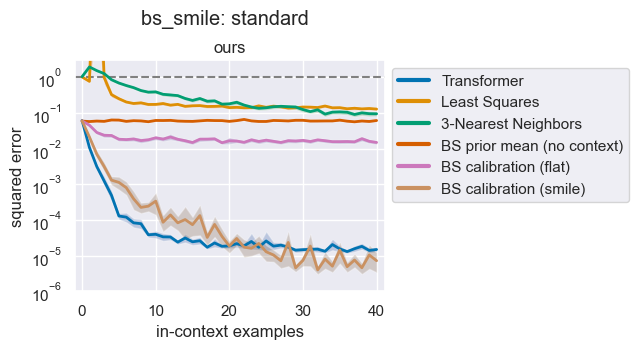

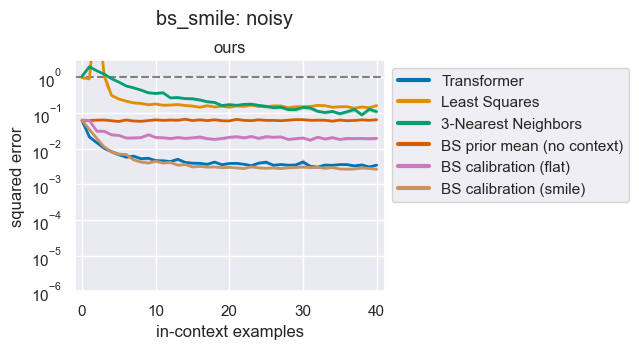

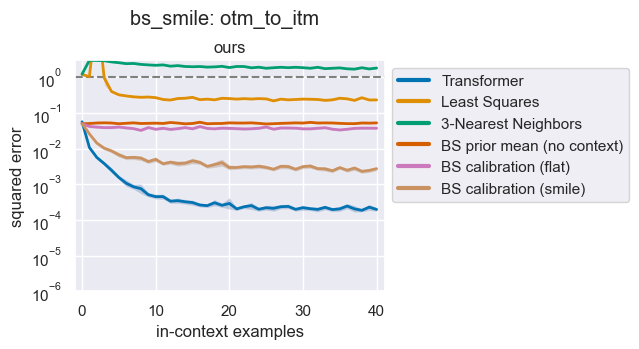

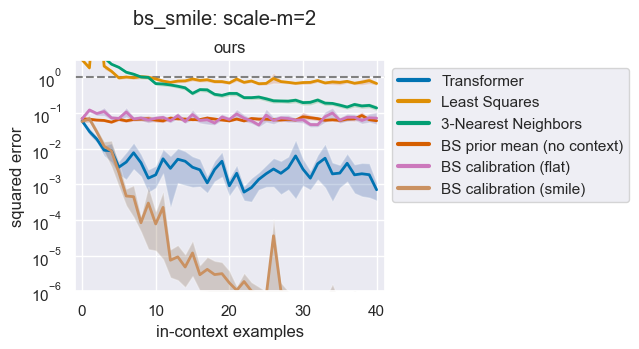

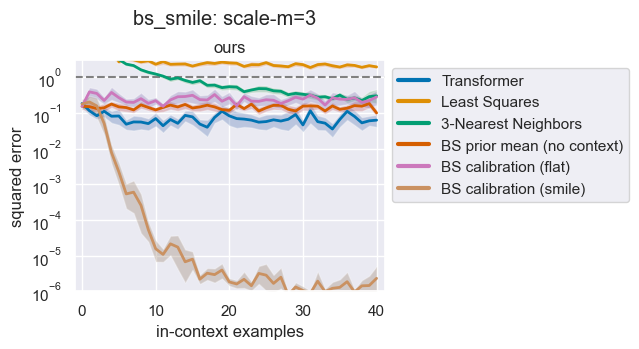

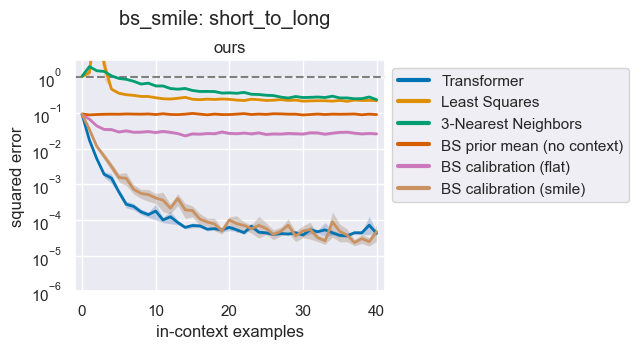

In [5]:
for task in tasks:
    plot_task(task)

# Clean vs. noisy (paper figure)

One figure per Black-Scholes task with the clean and noisy evals side by side, a shared y-axis, one legend underneath and the noise floor τ² in the noisy panel. Saved as `figures/<task>/clean_vs_noisy.png`.

In [ ]:
NOISE_STD = 0.05  # noise_std of the "noisy" eval in build_evals


def combined_figure(task, panels, filename, ymin=1e-6, noise_floor_in=None):
    """Evals of one run side by side: shared y-axis, one legend underneath.

    panels: [(eval name, panel title)]; noise_floor_in: eval name whose panel
    gets a line at the noise floor.
    """
    ours, n_dims = load_run(task, our_run_ids[task])
    fig, axes = plt.subplots(1, len(panels), figsize=(8, 3), sharey=True)
    handles, labels = [], []
    for ax, (name, title) in zip(axes, panels):
        plot_eval(task, name, ours[name], n_dims, title, ax=ax)
        ax.get_legend().remove()
        ax.set_ylim(ymin, 3)
        if name == noise_floor_in:
            # nothing can predict the query's own noise, so no method goes below this
            ax.axhline(NOISE_STD**2, ls=":", color="black", label=r"noise floor $\tau^2$")
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    for ax in axes[1:]:
        ax.set_ylabel("")

    # below the x-axis labels, spanning exactly the panels so it never widens the figure
    left, right = axes[0].get_position().x0, axes[-1].get_position().x1
    fig.legend(
        handles, labels, loc="upper left", bbox_to_anchor=(left, -0.08, right - left, 0),
        mode="expand", ncol=3, frameon=False, fontsize="small",
    )
    path = os.path.join(fig_dir, task, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path


for task in BS_TASKS:
    print(combined_figure(
        task, [("standard", "Clean"), ("noisy", "Noisy")], "clean_vs_noisy.png",
        noise_floor_in="noisy",
    ))

    # calibration drops below 1e-6 within a few examples here, hence the lower ymin
    print(combined_figure(
        task,
        [("standard", r"Moneyness $\times 1$"), ("scale-m=2", r"Moneyness $\times 2$"),
         ("scale-m=3", r"Moneyness $\times 3$")],
        "moneyness_scaling.png",
        ymin=1e-7,
    ))

# LaTeX tables

Writes the paper's tables to `tables/` from the same `metrics.json` files as the plots, so rerunning this notebook updates them. Only the `tabular` is written; caption and label stay in the paper:

```latex
\begin{table}[h]
  \caption{...}
  \label{tab:bs-results}
  \centering
  \small
  \input{tables/bs_results.tex}
\end{table}
```

In [ ]:
from tables import write_tables

table_dir = "../tables"
for path in write_tables(run_dir, our_run_ids, table_dir):
    print(path)
    print(open(path).read())

# Interactive setup

As in the authors' notebook, but with one of our models: load it and measure its in-context learning ability on a batch of random inputs.

In [6]:
from samplers import get_data_sampler
from tasks import get_task_sampler

In [7]:
task = "linear_regression"
run_path = os.path.join(run_dir, task, our_run_ids[task])

model, conf = get_model_from_run(run_path)

n_dims = conf.model.n_dims
batch_size = conf.training.batch_size

data_sampler = get_data_sampler(conf.training.data, n_dims)
task_sampler = get_task_sampler(
    conf.training.task,
    n_dims,
    batch_size,
    **conf.training.task_kwargs
)

In [8]:
task = task_sampler()
xs = data_sampler.sample_xs(b_size=batch_size, n_points=conf.training.curriculum.points.end)
ys = task.evaluate(xs)

In [9]:
with torch.no_grad():
    pred = model(xs, ys)

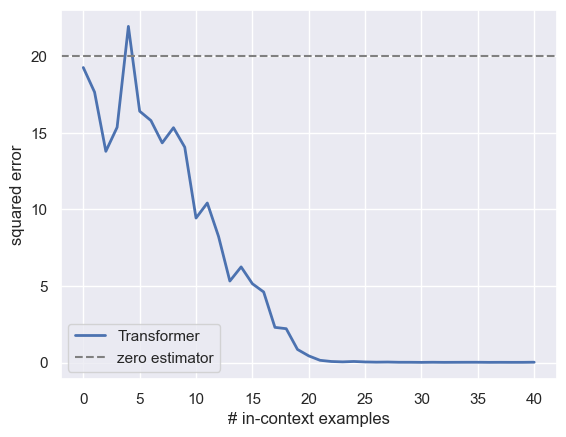

In [10]:
metric = task.get_metric()
loss = metric(pred, ys).numpy()

sparsity = conf.training.task_kwargs.sparsity if "sparsity" in conf.training.task_kwargs else None
baseline = {
    "linear_regression": n_dims,
    "sparse_linear_regression": sparsity,
    "relu_2nn_regression": n_dims,
    "decision_tree": 1,
    "bs_flat": 1,
    "bs_smile": 1,
}[conf.training.task]

plt.plot(loss.mean(axis=0), lw=2, label="Transformer")
plt.axhline(baseline, ls="--", color="gray", label="zero estimator")
plt.xlabel("# in-context examples")
plt.ylabel("squared error")
plt.legend()
plt.show()